# 3 - Usage Summary
We analyze the data about usage to see whether usage depends on the day of the week.  If the data shows such seasonality, we should take that into account when making posting recommendations.  Note that the usage is measured as number of connections per day: while this is not an exact measure of audience size, it is still the only reasonable proxy we can find at the moment.

### Section 1: Data Loading

Here we collect the data related to the daily usage of arXiv through the number of connections to the arXiv.org site on a particular day. It seems that arXiv was not tracking daily usage before Jan 1, 2024 (or, at least, it's not accessible via that API).  Hence, our data series will start on that date.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
arxiv_totals = pd.read_parquet("../data/arxiv-totals.parquet")

import time

usage_list = []

for index in arxiv_totals[arxiv_totals.index >= pd.Timestamp(2024, 1, 1)].index:
    day_usage_stats = pd.read_csv(
        "https://arxiv.org/stats/get_hourly?date=" + str(index.strftime("%Y%m%d"))
    )
    usage_list.append(tuple([index, day_usage_stats.node1.sum()]))

    # arXiv allows 1 request every 3 seconds, for our use here it means that it will take about 20 minutes
    time.sleep(3)

usage = pd.DataFrame(usage_list).set_index(0)

usage.to_parquet("../data/arxiv-usage.parquet")

/Users/ralbesia/anaconda3/envs/arxiv-heatmaps/lib/python3.13/site-packages/pandas/io/parquet.py:480: UserWarning: The DataFrame has non-str index name `[0]` which will be converted to string and not roundtrip correctly.
  impl.write(


### Section 2: Usage Analysis

Here, we analyze the data about usage to see whether usage depends on the day of the week.  If the data shows such seasonality, we should take that into account when making posting recommendations.  Note that the usage is measured as number of connections per day: while this is not an exact measure of audience size, it is still the only reasonable proxy we can find at the moment.

In [3]:
usage = (
    pd.read_parquet("../data/arxiv-usage.parquet")
    .reset_index()
    .rename(columns={"0": "date", 1: "connections"})
)
usage

,date,connections
0,2024-01-01,43626111
1,2024-01-02,54640750
2,2024-01-03,56101036
3,2024-01-04,50084378
4,2024-01-05,48182775
...,...,...
330,2025-04-07,57708551
331,2025-04-08,57728496
332,2025-04-09,56104215
333,2025-04-10,53120177


We create a new column in usage containing the day of the week for each entry.

In [4]:
from calendar import day_name
import pandas as pd

# Convert date column to datetime if not already
usage["date"] = pd.to_datetime(usage["date"])

# Add a new column for weekday names
usage["weekday"] = usage["date"].apply(lambda date: day_name[date.weekday()])

usage

,date,connections,weekday
0,2024-01-01,43626111,Monday
1,2024-01-02,54640750,Tuesday
2,2024-01-03,56101036,Wednesday
3,2024-01-04,50084378,Thursday
4,2024-01-05,48182775,Friday
...,...,...,...
330,2025-04-07,57708551,Monday
331,2025-04-08,57728496,Tuesday
332,2025-04-09,56104215,Wednesday
333,2025-04-10,53120177,Thursday


We start with a violin plot of the training dataset, split by day of the week.

<Axes: xlabel='weekday', ylabel='connections'>

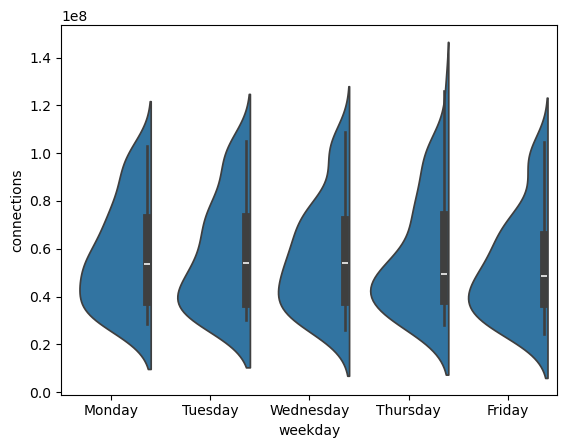

In [5]:
sns.violinplot(
    data=usage,
    x="weekday",
    y="connections",
    split=True,
)

It does not look like the date of the week matters much for the number of connections, possibly except for weekends.  Preprints are made public ("announced") on weekdays only, so it seems reasonable to restrict the dataset to weekdays.

<Axes: xlabel='weekday', ylabel='connections'>

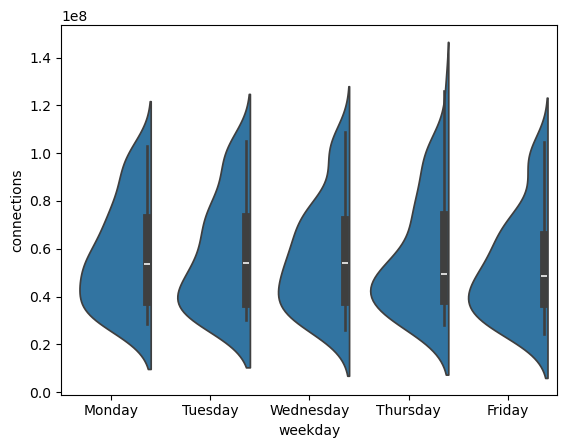

In [6]:
usage_weekdays = usage[(usage.weekday != "Saturday") & (usage.weekday != "Sunday")]
sns.violinplot(
    data=usage_weekdays,
    x="weekday",
    y="connections",
    split=True,
)

### Section 3: Weekday Effect Hypothesis Test

We now do hypothesis testing:
- _null hypothesis_: there is no contribution from the day of the week, so the model is average plus noise,
- _alternative hypothesis_: the day of the week has a contribution, so the model is linear regression on 5 one-hot encoded variables.

First, we produce the one-hot encoding of the `weekday` feature.

In [7]:
one_hot = (
    pd.get_dummies(usage_weekdays.weekday, dtype=int)
    .drop("Friday", axis=1)
    .iloc[:, [0, 2, 3, 1]]
)
usage_weekdays = usage_weekdays.join(one_hot)

Then we use `statsmodels` to compare the model with no feature with the model regressed on `Monday`, `Tuesday`, `Wednesday`, and `Thursday`, by computing the F-test p-value.

In [9]:
import statsmodels.formula.api as smf

data = {
    "C": usage_weekdays.connections,
    "M": usage_weekdays.Monday,
    "Tu": usage_weekdays.Tuesday,
    "W": usage_weekdays.Wednesday,
    "Th": usage_weekdays.Thursday,
}

reduced_model = smf.ols("C ~ 1", data=data).fit()
full_model = smf.ols("C ~ M + Tu + W + Th", data=data).fit()

f_test = full_model.compare_f_test(reduced_model)
print("F-test p-value:", f_test[1])

F-test p-value: 0.69485095220215


Hence, if the usage data was generated by a normal probability distribution centered at the average number of connections ($C = C_0 + \varepsilon$), we would see this much improvement when we fit $C = M + Tu + W + Th + \varepsilon$ instead about $69.5 \%$ of the time.  This is not at all a rare thing to happen, so evidence is supporting the independence of the number of connections on the day of the week.

In [10]:
reduced_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      C   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 24 Jun 2025   Prob (F-statistic):                nan
Time:                        10:30:22   Log-Likelihood:                -6144.1
No. Observations:                 335   AIC:                         1.229e+04
Df Residuals:                     334   BIC:                         1.229e+04
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.659e+07   1.22e+06     46.304      0.000    5.42e+07     5.9e+07
==============================================================================
Omnibus:                       28.208   Durbin-Watson:                   0.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.823
Skew:                           0.650   Prob(JB):                     9.08e-07
Kurtosis:                       2.450   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Note that the number of connections seems to depend on some other seasonal feature, but if we limit our forecasting to the week then they don't appear to be relevant.

<Axes: xlabel='Date', ylabel='Connections'>

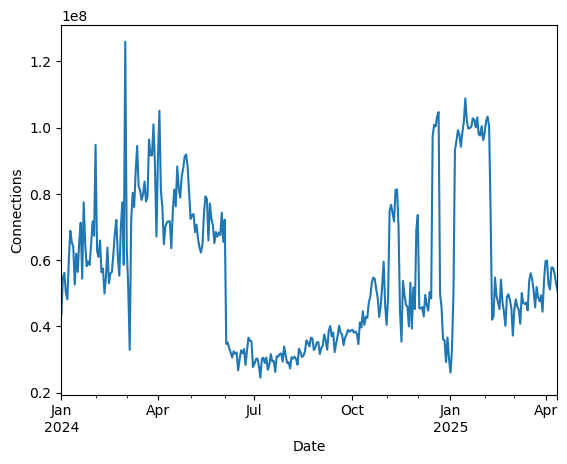

In [11]:
pd.read_parquet("../data/arxiv-usage.parquet").plot(
    xlabel="Date", ylabel="Connections", legend=False
)

### Section 4: Correlation with Posting Activity

The usage data does not distinguish between categories, hence here we extract the total number of article appearances on each day by summing the rows of `data/arxiv-totals.parquet`.

In [ ]:
# Create daily totals (row sums)
totals = pd.read_parquet("../data/arxiv-totals.parquet")

# Ensure the index is in datetime format (if not already)
totals.index = pd.to_datetime(totals.index)

# Filter the DataFrame from 2024-01-01 onwards
totals_recent = totals.loc[totals.index >= "2024-01-01"]

# Sum across columns (i.e., across all categories) for each row (i.e., each date)
totals_sum = totals_recent.sum(axis=1)

# Convert the resulting Series into a DataFrame with a meaningful column name
totals_sum_df = totals_sum.to_frame(name="total_appearances")

totals_sum_df

,total_appearances
date,
2024-01-01,1792.0
2024-01-02,950.0
2024-01-03,754.0
2024-01-04,961.0
2024-01-05,991.0
...,...
2025-04-07,2450.0
2025-04-08,1968.0
2025-04-09,1693.0


We verify if there is a correlation between the total appearances and the number of connections on a given day. First, we drop weekends.

In [21]:
usage = usage[(usage.weekday != "Saturday") & (usage.weekday != "Sunday")]

In [22]:
# type: ignore
from scipy.stats import pearsonr

# Flatten to 1D if needed
x = totals_sum_df["total_appearances"].values.flatten()
y = usage.connections

# Compute Pearson correlation
r, p_value = pearsonr(x, y)

# Print result
print(f"Correlation: {float(r):.4f}, p-value: {float(p_value):.4e}")

Correlation: 0.0095, p-value: 8.6293e-01


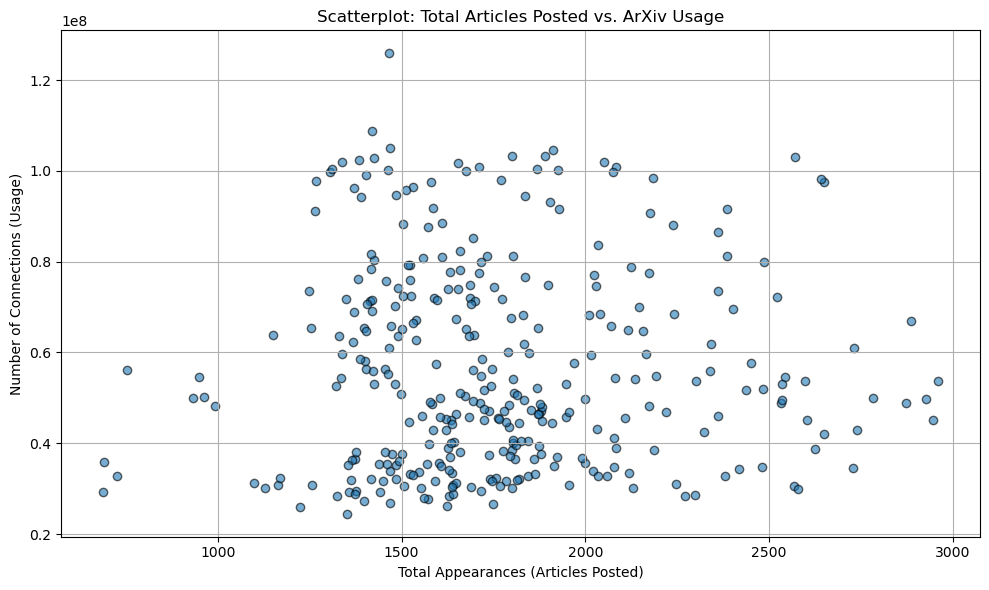

In [23]:
# Join the two on the index (i.e., date)
combined = totals_sum_df.join(usage.set_index("date", inplace=False), how="inner")

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the scatterplot
plt.scatter(
    combined["total_appearances"], combined["connections"], alpha=0.6, edgecolor="k"
)

# Add labels and title
plt.xlabel("Total Appearances (Articles Posted)")
plt.ylabel("Number of Connections (Usage)")
plt.title("Scatterplot: Total Articles Posted vs. ArXiv Usage")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

### Section 5: Conclusion

Key Findings:
- Usage is relatively stable across weekdays, with no statistically significant weekday effect (p ~ 0.695 > 0.05).
- The correlation between daily arXiv usage and total article postings is minuscule and statistically non-significant (r = 0.0095, p ~ 0.863).

We can safely ignore usage data, and make posting recommendations based only on the predicted number of posted papers.
